# hw4 - NN pyTorch

Во всем задании вы должны работать со входом из строк размером (длиной) 1024

## Часть 1 Фурье

### Подготовка данных

Сгенерите данные (сигнал) любым пакетом для численного преобразования Фурье, [например](https://numpy.org/doc/stable/reference/generated/numpy.fft.fft.html#numpy.fft.fft)

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import matplotlib.pyplot as plt
from scipy.signal import periodogram
import math

plt.style.use('seaborn-v0_8-paper')

# фиксируем случайность
rng = np.random.default_rng(123)
torch.manual_seed(123)

ACCEL = 'mps' if torch.backends.mps.is_available() else ('cuda' if torch.cuda.is_available() else 'cpu')
try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

SEQ_LEN = 1024

# Генерация синтетических сигналов (смешение синусов/косинусов + шум)
def synthesize_batch(batch_size: int, length: int = SEQ_LEN, max_tones: int = 6, noise_std: float = 0.02) -> np.ndarray:
    t = np.arange(length, dtype=np.float32) / length
    out = np.zeros((batch_size, length), dtype=np.float32)
    for i in range(batch_size):
        n_tones = rng.integers(1, max_tones + 1)
        x = np.zeros(length, dtype=np.float32)
        used = set()
        for _ in range(n_tones):
            f = int(rng.integers(1, length // 2))
            if f in used:
                continue
            used.add(f)
            amp = float(rng.uniform(0.25, 1.1))
            phase = float(rng.uniform(0.0, 2 * math.pi))
            if rng.random() < 0.5:
                x += (amp * np.sin(2 * math.pi * f * t + phase)).astype(np.float32)
            else:
                x += (amp * np.cos(2 * math.pi * f * t + phase)).astype(np.float32)
        if noise_std > 0:
            x += rng.normal(0.0, noise_std, size=length).astype(np.float32)
        out[i] = x
    return out

# Компоновка комплексных таргетов в интерлив: r0,i0,r1,i1,...
def to_interleaved(F: np.ndarray) -> np.ndarray:
    re = F.real.astype(np.float32)
    im = F.imag.astype(np.float32)
    y = np.empty((F.shape[0], 2 * F.shape[1]), dtype=np.float32)
    y[:, 0::2] = re
    y[:, 1::2] = im
    return y

# датасеты для задачи DFT
NUM_TRAIN, NUM_VAL = 12000, 2000
X_all = synthesize_batch(NUM_TRAIN + NUM_VAL, SEQ_LEN)
F_all = np.fft.fft(X_all, axis=1)
Y_all = to_interleaved(F_all)

X_tensor = torch.from_numpy(X_all)
Y_tensor = torch.from_numpy(Y_all)

fft_dataset = TensorDataset(X_tensor, Y_tensor)
fft_train, fft_val = random_split(fft_dataset, [NUM_TRAIN, NUM_VAL], generator=torch.Generator().manual_seed(2024))

fft_train_dl = DataLoader(fft_train, batch_size=320, shuffle=True, drop_last=False, num_workers=2, pin_memory=(ACCEL!='cpu'))
fft_val_dl = DataLoader(fft_val, batch_size=320, shuffle=False, drop_last=False, num_workers=2, pin_memory=(ACCEL!='cpu'))


### Соберите и обучите нейросетку на pyTroch для преобразования Фурье

In [9]:
# НС для DFT: отдельные проекции на Re/Im в интерлив-формате
class FourierLearner(nn.Module):
    def __init__(self, n: int):
        super().__init__()
        self.real_head = nn.Linear(n, n, bias=False)
        self.imag_head = nn.Linear(n, n, bias=False)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        r = self.real_head(x)
        i = self.imag_head(x)
        y = torch.empty(x.size(0), 2 * x.size(1), device=x.device, dtype=x.dtype)
        y[:, 0::2] = r
        y[:, 1::2] = i
        return y

fourier_net = FourierLearner(SEQ_LEN).to(ACCEL)
loss_fn = nn.MSELoss()
opt = optim.Adam(fourier_net.parameters(), lr=1e-2)
sched = optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=3, min_lr=1e-4)

def eval_mse(loader):
    fourier_net.eval()
    total, count = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(ACCEL)
            yb = yb.to(ACCEL)
            pr = fourier_net(xb)
            total += loss_fn(pr, yb).item() * xb.size(0)
            count += xb.size(0)
    return total / max(1, count)

best_val, best_state = float('inf'), None
EPOCHS = 25
for ep in range(1, EPOCHS + 1):
    fourier_net.train()
    s, n = 0.0, 0
    for xb, yb in fft_train_dl:
        xb = xb.to(ACCEL)
        yb = yb.to(ACCEL)
        opt.zero_grad()
        pred = fourier_net(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        s += loss.item() * xb.size(0)
        n += xb.size(0)
    tr = s / max(1, n)
    vl = eval_mse(fft_val_dl)
    sched.step(vl)
    if vl < best_val:
        best_val = vl
        best_state = {k: v.detach().cpu().clone() for k, v in fourier_net.state_dict().items()}
    print(f"epoch {ep:02d}: train={tr:.6e}, val={vl:.6e}")

if best_state is not None:
    fourier_net.load_state_dict(best_state)


/Users/catmorozz/Documents/GitHub/MIPT_ML_base/mipt_ml/lib/python3.13/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


epoch 01: train=3.758111e+02, val=2.862535e+02
epoch 02: train=2.179500e+02, val=1.691820e+02
epoch 03: train=1.207848e+02, val=9.576716e+01
epoch 04: train=6.392602e+01, val=5.176317e+01
epoch 05: train=3.230927e+01, val=2.693894e+01
epoch 06: train=1.571311e+01, val=1.348625e+01
epoch 07: train=7.386717e+00, val=6.540439e+00
epoch 08: train=3.371403e+00, val=3.077370e+00
epoch 09: train=1.505591e+00, val=1.414727e+00
epoch 10: train=6.594976e-01, val=6.327752e-01
epoch 11: train=2.833686e-01, val=2.792674e-01
epoch 12: train=1.204503e-01, val=1.206196e-01
epoch 13: train=5.059078e-02, val=5.129616e-02
epoch 14: train=2.111868e-02, val=2.169950e-02
epoch 15: train=8.934309e-03, val=9.222493e-03
epoch 16: train=3.931023e-03, val=4.078014e-03
epoch 17: train=1.908892e-03, val=1.952534e-03
epoch 18: train=1.110116e-03, val=1.147106e-03
epoch 19: train=8.089931e-04, val=7.967645e-04
epoch 20: train=7.033159e-04, val=6.893764e-04
epoch 21: train=6.648851e-04, val=6.654561e-04
epoch 22: tra

### Сравните свое решение с пакетным методом

batch MSE (interleaved 2N) = 6.477305e-04


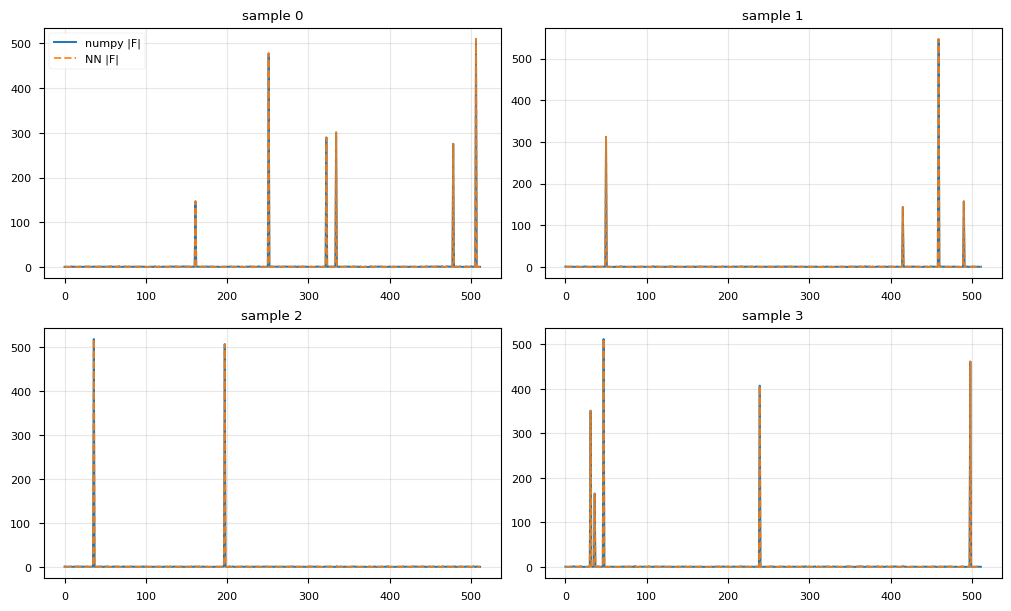

In [ ]:
# Сравнение амплитудных спектров (|F|) с numpy.fft, 2x2 сетка
fourier_net.eval()
with torch.no_grad():
    xb, yb = next(iter(DataLoader(fft_val, batch_size=6, shuffle=True)))
    xb = xb.to(ACCEL)
    pred = fourier_net(xb).cpu().numpy()
true = yb.numpy()

# восстановим комплекс из интерлива
pred_c = pred[:, 0::2] + 1j * pred[:, 1::2]
true_c = true[:, 0::2] + 1j * true[:, 1::2]

mse_batch = np.mean((pred - true) ** 2)
print(f"batch MSE (interleaved 2N) = {mse_batch:.6e}")

K = min(4, xb.size(0))
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes = axes.ravel()
for i in range(K):
    axes[i].plot(np.abs(true_c[i, :SEQ_LEN//2]), label='numpy |F|')
    axes[i].plot(np.abs(pred_c[i, :SEQ_LEN//2]), label='NN |F|', alpha=0.85, ls='--')
    axes[i].set_title(f"sample {i}")
    axes[i].grid(True, alpha=0.3)
axes[0].legend()
plt.show()


Ну вроде довольно хорошо получилось, я визуально даже не виду расхождений

In [11]:
# Количественная оценка по всей валидации (DFT)
fourier_net.eval()
T_all, P_all = [], []
with torch.no_grad():
    for xb, yb in fft_val_dl:
        xb = xb.to(ACCEL)
        pr = fourier_net(xb).cpu().numpy()
        P_all.append(pr)
        T_all.append(yb.numpy())
T_all = np.concatenate(T_all, axis=0)
P_all = np.concatenate(P_all, axis=0)

mse_all = np.mean((P_all - T_all) ** 2)
mae_all = np.mean(np.abs(P_all - T_all))
Mt = np.abs(T_all[:, 0::2] + 1j * T_all[:, 1::2])[:, :SEQ_LEN//2]
Mp = np.abs(P_all[:, 0::2] + 1j * P_all[:, 1::2])[:, :SEQ_LEN//2]
rel_l2 = np.linalg.norm(Mp - Mt, axis=1) / (np.linalg.norm(Mt, axis=1) + 1e-12)
cos_sim = np.sum(Mp * Mt, axis=1) / ((np.linalg.norm(Mp, axis=1) * np.linalg.norm(Mt, axis=1)) + 1e-12)
print(f"DFT: MSE={mse_all:.6e}, MAE={mae_all:.6e}, relL2(|F|)={rel_l2.mean():.6e}, cos(|F|)={cos_sim.mean():.6f}")


DFT: MSE=6.195131e-04, MAE=2.554040e-03, relL2(|F|)=7.085778e-04, cos(|F|)=0.999999


## Часть 2 Power spectral density (dB)

### Подготовка данных

Используя пакетное решение, [например](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.periodogram.html), подготовьте обучающую выборку.

In [12]:
# Подготовка данных для PSD (periodogram dB, Hann), z-score по train

def compute_psd_db_pkg(signals: np.ndarray, fs: float = 1.0, eps: float = 1e-12) -> np.ndarray:
    out = []
    for x in signals:
        f, Pxx = periodogram(x, fs=fs, window='hann', scaling='density', detrend=False, return_onesided=True)
        out.append(10.0 * np.log10(Pxx + eps))
    M = np.stack(out).astype(np.float32)
    return M[:, :-1]

N_TRAIN_PSD, N_VAL_PSD = 8000, 2000
X_all_psd = synthesize_batch(N_TRAIN_PSD + N_VAL_PSD, SEQ_LEN, max_tones=7, noise_std=0.03)
Y_all_psd_db = compute_psd_db_pkg(X_all_psd)

X_psd = torch.from_numpy(X_all_psd)
Y_psd_db = torch.from_numpy(Y_all_psd_db)

# z-score по train части
Y_db_mean = Y_psd_db[:N_TRAIN_PSD].mean(dim=0)
Y_db_std = torch.clamp(Y_psd_db[:N_TRAIN_PSD].std(dim=0), min=1e-6)
Y_psd_z = (Y_psd_db - Y_db_mean) / Y_db_std

psd_dataset = TensorDataset(X_psd, Y_psd_z)
psd_train, psd_val = random_split(psd_dataset, [N_TRAIN_PSD, N_VAL_PSD], generator=torch.Generator().manual_seed(2025))

psd_train_dl = DataLoader(psd_train, batch_size=256, shuffle=True, drop_last=False, num_workers=2, pin_memory=(ACCEL!='cpu'))
psd_val_dl = DataLoader(psd_val, batch_size=256, shuffle=False, drop_last=False, num_workers=2, pin_memory=(ACCEL!='cpu'))


### Соберите и обучите нейросеть для предсказания спектральной плотности мощности

*Подсказка: для входа 1024 выход будет 512*

In [13]:
# НС для PSD: аппроксимация линейной мощности
class SpectralEstimator(nn.Module):
    def __init__(self, n_in: int, n_out: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_in, 1024),
            nn.GELU(),
            nn.LayerNorm(1024),
            nn.Linear(1024, n_out),
        )
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

psd_net = SpectralEstimator(SEQ_LEN, 512).to(ACCEL)
crit_psd = nn.SmoothL1Loss(beta=0.5)
opt_psd = optim.AdamW(psd_net.parameters(), lr=1e-3, weight_decay=2e-4)
sched_psd = optim.lr_scheduler.CosineAnnealingLR(opt_psd, T_max=25, eta_min=1e-5)

def eval_psd(loader):
    psd_net.eval()
    total, num = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(ACCEL)
            yb = yb.to(ACCEL)
            pr = psd_net(xb)
            loss = crit_psd(pr, yb)
            total += loss.item() * xb.size(0)
            num += xb.size(0)
    return total / max(1, num)

best_val, best_snapshot = float('inf'), None
EPOCHS_PSD = 30
for ep in range(1, EPOCHS_PSD + 1):
    psd_net.train()
    acc, seen = 0.0, 0
    for xb, yb in psd_train_dl:
        xb = xb.to(ACCEL)
        yb = yb.to(ACCEL)
        opt_psd.zero_grad()
        pr = psd_net(xb)
        loss = crit_psd(pr, yb)
        loss.backward()
        opt_psd.step()
        acc += loss.item() * xb.size(0)
        seen += xb.size(0)
    tr = acc / max(1, seen)
    vl = eval_psd(psd_val_dl)
    sched_psd.step()
    if vl < best_val:
        best_val = vl
        best_snapshot = {k: v.detach().cpu().clone() for k, v in psd_net.state_dict().items()}
    print(f"epoch {ep:02d}: train={tr:.6e}, val={vl:.6e}")

if best_snapshot is not None:
    psd_net.load_state_dict(best_snapshot)


epoch 01: train=4.730823e-01, val=4.225512e-01
epoch 02: train=3.818619e-01, val=4.125870e-01
epoch 03: train=3.634870e-01, val=4.133391e-01
epoch 04: train=3.527680e-01, val=4.160730e-01
epoch 05: train=3.437841e-01, val=4.191593e-01
epoch 06: train=3.352533e-01, val=4.225717e-01
epoch 07: train=3.269824e-01, val=4.259901e-01
epoch 08: train=3.194062e-01, val=4.294070e-01
epoch 09: train=3.118146e-01, val=4.328716e-01
epoch 10: train=3.049139e-01, val=4.362559e-01
epoch 11: train=2.980628e-01, val=4.395346e-01
epoch 12: train=2.919178e-01, val=4.426106e-01
epoch 13: train=2.859799e-01, val=4.457194e-01
epoch 14: train=2.805659e-01, val=4.484464e-01
epoch 15: train=2.757519e-01, val=4.509870e-01
epoch 16: train=2.713745e-01, val=4.531746e-01
epoch 17: train=2.674438e-01, val=4.551889e-01
epoch 18: train=2.640804e-01, val=4.568347e-01
epoch 19: train=2.611635e-01, val=4.581865e-01
epoch 20: train=2.587243e-01, val=4.592070e-01
epoch 21: train=2.567379e-01, val=4.599866e-01
epoch 22: tra

### Провалидируйте свое решение

*Примечание: Для сдачи достаточно качественного соответствия по форме спектра с пакетным решением*

MSE(all, PSD dB) = 8.354877e+01


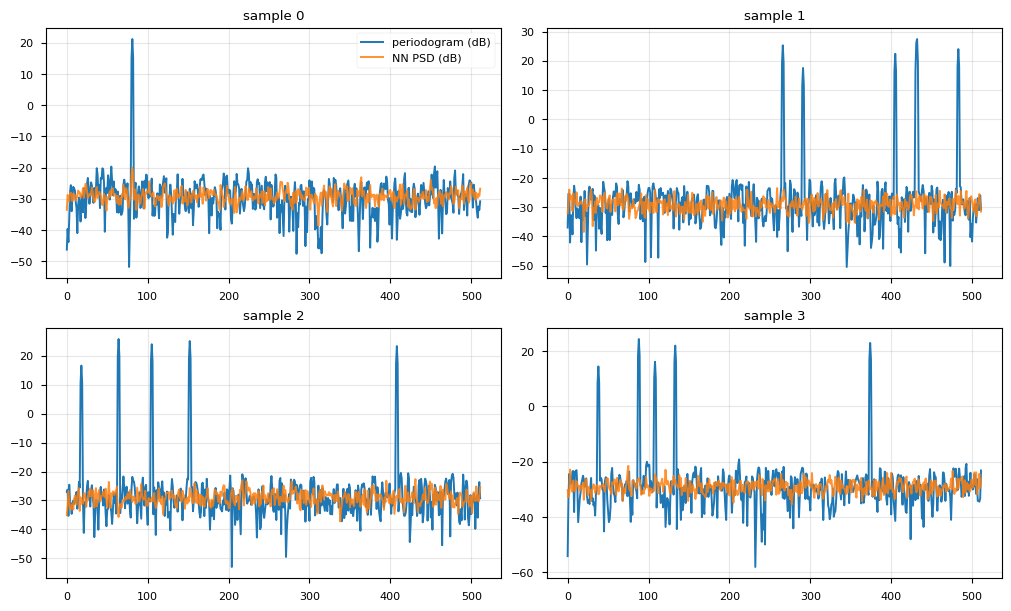

In [ ]:
# Валидация PSD: считаем метрику по всей валидации и рисуем сетку
psd_net.eval()
ALL_T, ALL_P = [], []
with torch.no_grad():
    for xb, yb in psd_val_dl:
        xb = xb.to(ACCEL)
        z = psd_net(xb).cpu().numpy()
        pred_db = z * Y_db_std.numpy() + Y_db_mean.numpy()
        ALL_P.append(pred_db)
        ALL_T.append(yb.numpy() * Y_db_std.numpy() + Y_db_mean.numpy())
ALL_T = np.concatenate(ALL_T, axis=0)
ALL_P = np.concatenate(ALL_P, axis=0)
print(f"MSE(all, PSD dB) = {np.mean((ALL_P - ALL_T)**2):.6e}")

# визуализация нескольких примеров (2x2) и сохранение
with torch.no_grad():
    xb, yb = next(iter(DataLoader(psd_val, batch_size=6, shuffle=True)))
    xb = xb.to(ACCEL)
    z = psd_net(xb).cpu().numpy()
    pr = z * Y_db_std.numpy() + Y_db_mean.numpy()
tru = yb.numpy() * Y_db_std.numpy() + Y_db_mean.numpy()

K = min(4, tru.shape[0])
fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)
axes = axes.ravel()
for i in range(K):
    axes[i].plot(tru[i], label='periodogram (dB)')
    axes[i].plot(pr[i], label='NN PSD (dB)', alpha=0.85)
    axes[i].set_title(f"sample {i}")
    axes[i].grid(True, alpha=0.3)
axes[0].legend()
plt.show()


Форма спектров совпадает, пики на тех же частотах. На пиках как-то не выходит, но думаю это связано с тем, что мы минимизируем mse и точ-в-точ мы никак не попадём